In [21]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Admission_Predict_Ver1.1.csv')

# Display the first few rows to verify
print(df.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


In [22]:
import pandas as pd

# Load the dataset (already done, but included for completeness)
df = pd.read_csv('/content/Admission_Predict_Ver1.1.csv')

# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\n")

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n")

# Display basic statistical summary
print("Statistical Summary:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB
None


Missing Values:
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


Statistical Summary:
       Serial No.   GRE Score  TOEFL 

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Admission_Predict_Ver1.1.csv')

# Set Seaborn style
sns.set_style('whitegrid')

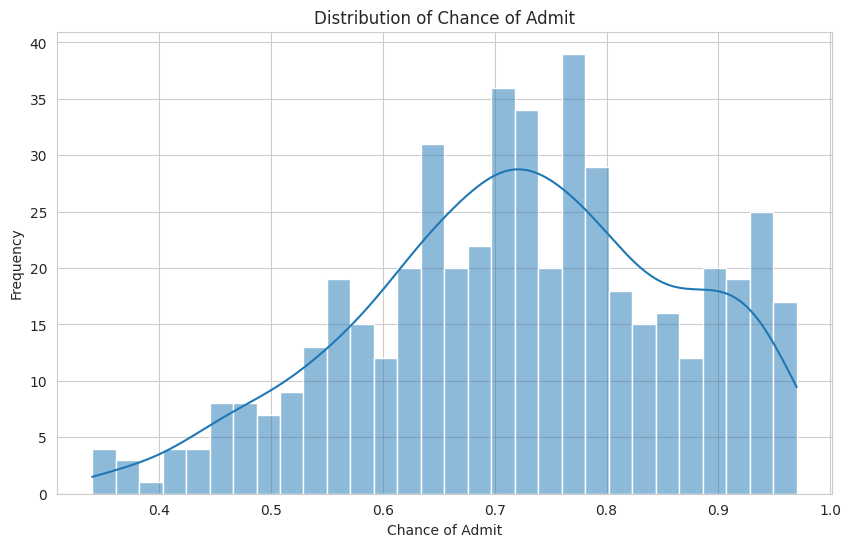

In [28]:
# 1. Distribution of Chance of Admit
plt.figure(figsize=(10, 6))
sns.histplot(df['Chance of Admit '], bins=30, kde=True)
plt.title('Distribution of Chance of Admit')
plt.xlabel('Chance of Admit')
plt.ylabel('Frequency')
plt.show()

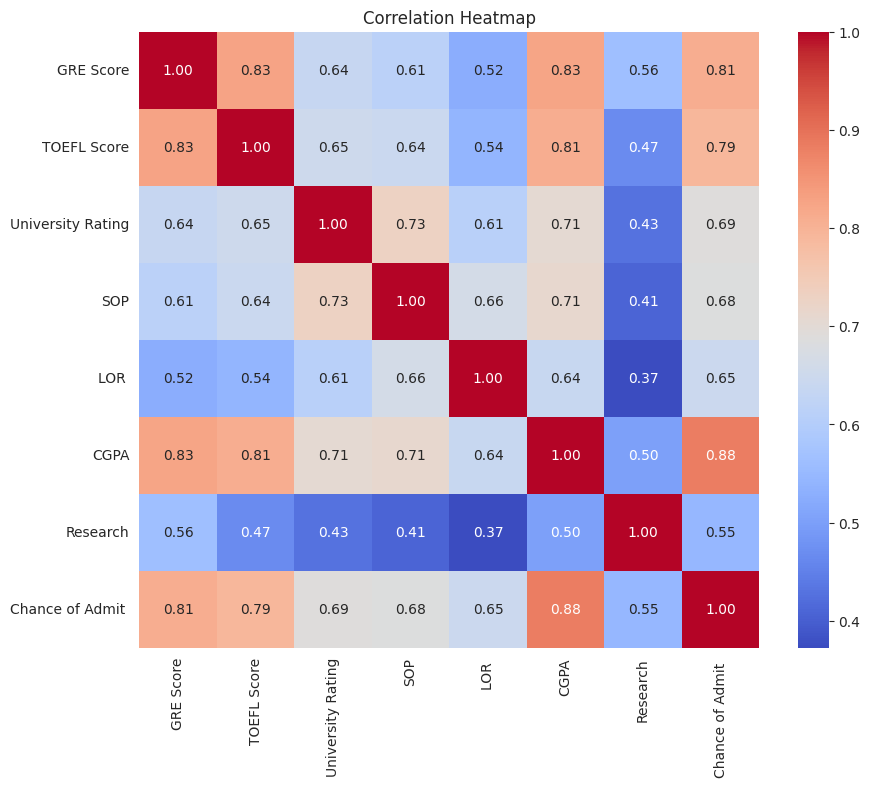

In [29]:
# 2. Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.drop('Serial No.', axis=1).corr()  # Exclude Serial No. as it's an index
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

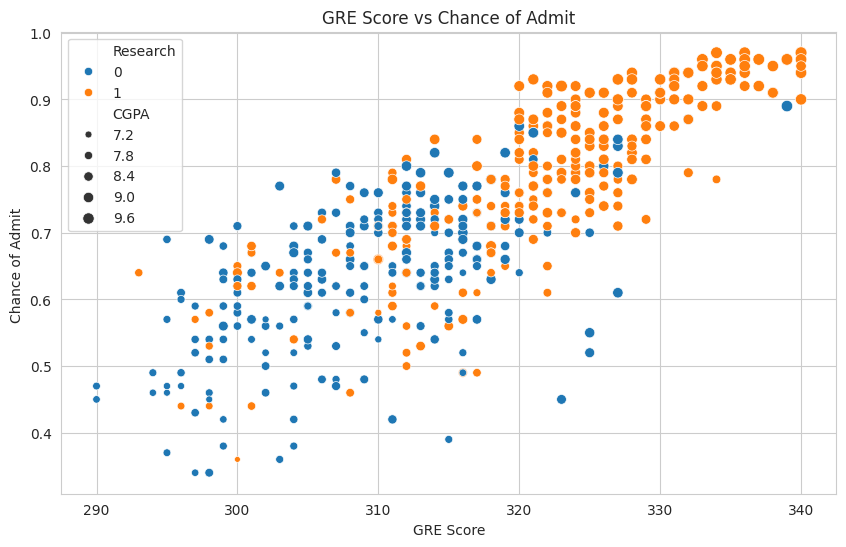

In [30]:
# 3. Scatter plot of GRE Score vs Chance of Admit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GRE Score', y='Chance of Admit ', hue='Research', size='CGPA', data=df)
plt.title('GRE Score vs Chance of Admit')
plt.show()

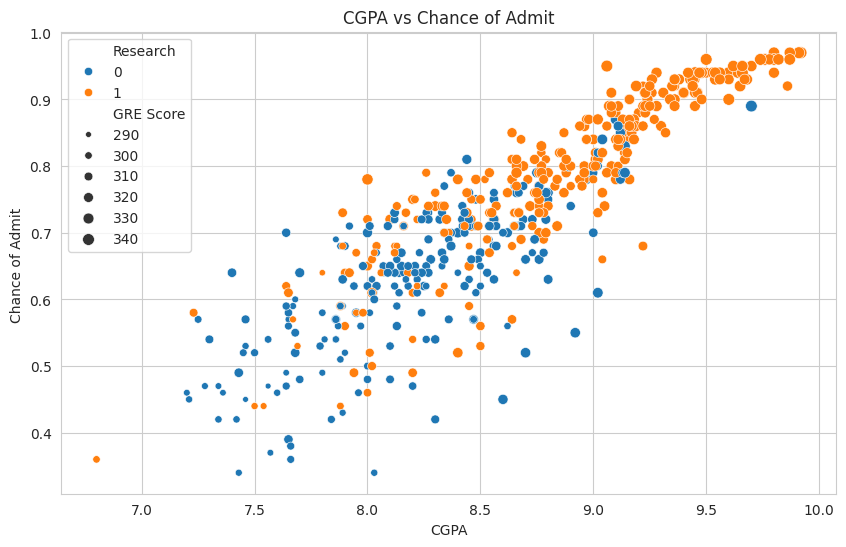

In [31]:
# 4. Scatter plot of CGPA vs Chance of Admit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CGPA', y='Chance of Admit ', hue='Research', size='GRE Score', data=df)
plt.title('CGPA vs Chance of Admit')
plt.show()

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('/content/Admission_Predict_Ver1.1.csv')

In [33]:
# Drop 'Serial No.' as it's not a feature
df = df.drop('Serial No.', axis=1)

In [34]:
# Define features (X) and target (y)
X = df.drop('Chance of Admit ', axis=1)  # All columns except target
y = df['Chance of Admit ']  # Target variable

In [35]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# Print shapes to verify
print("Training set shape (X_train_scaled):", X_train_scaled.shape)
print("Testing set shape (X_test_scaled):", X_test_scaled.shape)
print("Training target shape (y_train):", y_train.shape)
print("Testing target shape (y_test):", y_test.shape)

Training set shape (X_train_scaled): (400, 7)
Testing set shape (X_test_scaled): (100, 7)
Training target shape (y_train): (400,)
Testing target shape (y_test): (100,)


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('/content/Admission_Predict_Ver1.1.csv')

In [39]:
# Drop 'Serial No.' as it's not a feature
df = df.drop('Serial No.', axis=1)

In [40]:
# Define features (X) and target (y)
X = df.drop('Chance of Admit ', axis=1)
y = df['Chance of Admit ']

In [41]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [44]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

In [45]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [46]:
# Print evaluation metrics
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)


Mean Squared Error (MSE): 0.0037046553987884136
R-squared (R²): 0.8188432567829627


In [47]:
# Optional: Display first few actual vs predicted values
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nFirst 5 Actual vs Predicted Values:")
print(comparison.head())


First 5 Actual vs Predicted Values:
     Actual  Predicted
361    0.93   0.914575
73     0.84   0.795181
374    0.39   0.572660
155    0.77   0.707370
104    0.74   0.815883


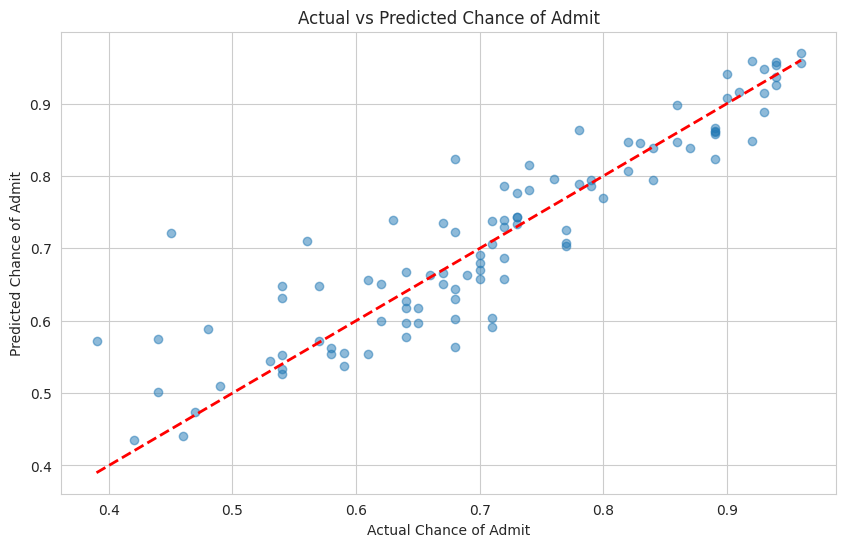

In [48]:
# Set Seaborn style
sns.set_style('whitegrid')

# 1. Scatter plot of Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted Chance of Admit')
plt.show()

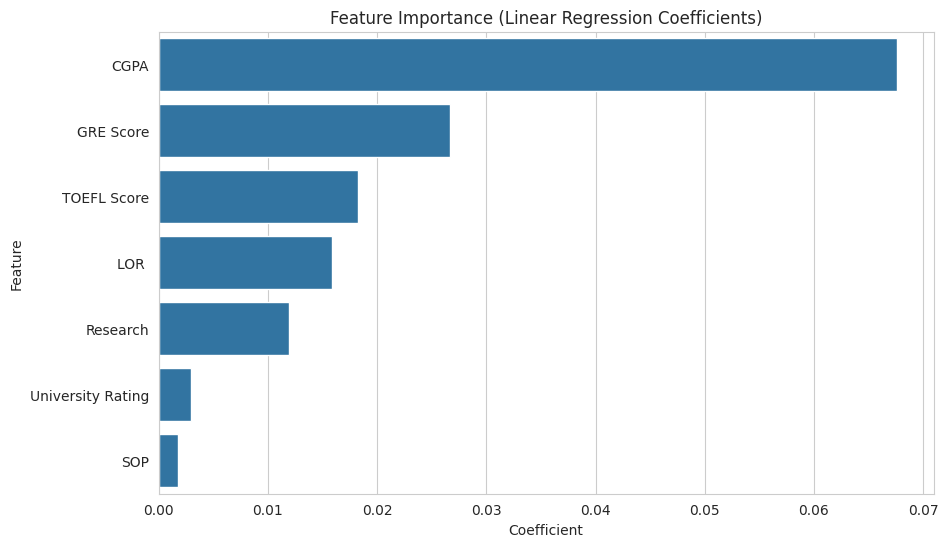

In [49]:
# 2. Feature importance (coefficients)
feature_names = X.columns
coefficients = model.coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.sort_values('Coefficient', ascending=False))
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.show()

In [53]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

In [54]:
# Dictionary to store results
results = {'Model': [], 'MSE': [], 'R²': []}

In [56]:
# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results['Model'].append(name)
    results['MSE'].append(mse)
    results['R²'].append(r2)


In [57]:
# Create a DataFrame for results
results_df = pd.DataFrame(results)

In [58]:
# Print the comparison table
print("Model Performance Comparison:")
print(results_df)


Model Performance Comparison:
               Model       MSE        R²
0  Linear Regression  0.003705  0.818843
1      Random Forest  0.004322  0.788675
2  Gradient Boosting  0.004445  0.782626


In [59]:
# Optional: Display first few predictions for the best model (based on R²)
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best})
print(f"\nFirst 5 Actual vs Predicted Values for {best_model_name}:")
print(comparison.head())


First 5 Actual vs Predicted Values for Linear Regression:
     Actual  Predicted
361    0.93   0.914575
73     0.84   0.795181
374    0.39   0.572660
155    0.77   0.707370
104    0.74   0.815883


In [61]:
# Save the model and scaler
import joblib
joblib.dump(model, 'admission_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [65]:
# Function to predict Chance of Admit for new data
def predict_admission(gre_score, toefl_score, university_rating, sop, lor, cgpa, research):
    # Create a DataFrame with the input data
    input_data = pd.DataFrame({
        'GRE Score': [gre_score],
        'TOEFL Score': [toefl_score],
        'University Rating': [university_rating],
        'SOP': [sop],
        'LOR ': [lor],
        'CGPA': [cgpa],
        'Research': [research]
    })

    # Scale the input data
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = model.predict(input_scaled)[0]

    # Ensure prediction is between 0 and 1
    prediction = max(0, min(1, prediction))

    return prediction

In [68]:
# Test the prediction function with sample data
sample_prediction = predict_admission(
    gre_score=320,
    toefl_score=110,
    university_rating=4,
    sop=4.0,
    lor=4.5,
    cgpa=8.5,
    research=1
)
print(f"Predicted Chance of Admit for sample profile: {sample_prediction:.3f}")

Predicted Chance of Admit for sample profile: 0.761


In [69]:
# Optional: Save test set predictions for reference
y_pred = model.predict(X_test_scaled)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison.to_csv('test_predictions.csv', index=False)
print("Test set predictions saved to 'test_predictions.csv'")

Test set predictions saved to 'test_predictions.csv'
